<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       163
           1       0.84      0.68      0.75       104

    accuracy                           0.82       267
   macro avg       0.83      0.80      0.81       267
weighted avg       

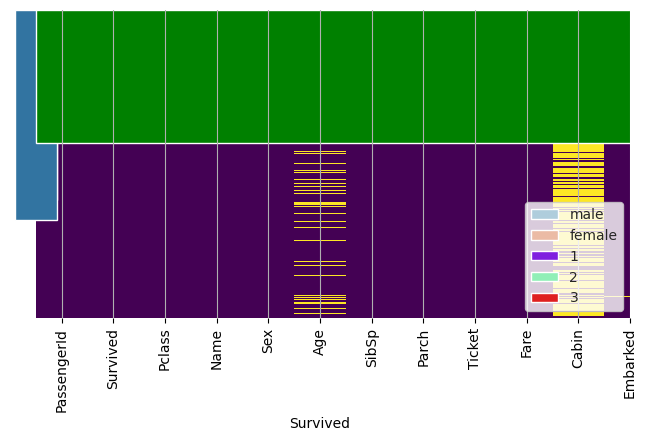

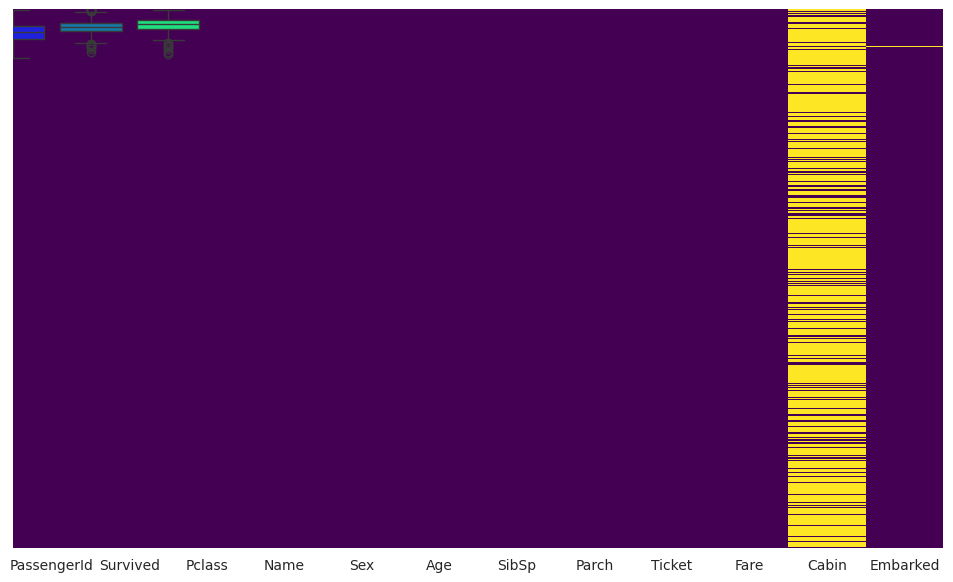

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

train = pd.read_csv('/content/titanic_train.csv')

train.head()

sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Survived', data=train, palette='RdBu_r', legend=False)

sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')

sns.countplot(x='Survived', hue='Pclass', data=train, palette='rainbow')

sns.histplot(train['Age'].dropna(), kde=False, color='darkred', bins=30)

train['Age'].hist(bins=30, color='darkred', alpha=0.7)

sns.countplot(x='SibSp', data=train)

train['Fare'].hist(color='green', bins=40, figsize=(8, 4))

plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass', y='Age', hue='Pclass', data=train, palette='winter', legend=False)

def impute_age(cols):
    Age = cols['Age']
    Pclass = cols['Pclass']
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

train.drop('Cabin', axis=1, inplace=True)

train.head()

train.dropna(inplace=True)

train.info()

sex = pd.get_dummies(train['Sex'], drop_first=True)
embark = pd.get_dummies(train['Embarked'], drop_first=True)

train.drop(['Sex', 'Embarked', 'Name', 'Ticket'], axis=1, inplace=True)

train = pd.concat([train, sex, embark], axis=1)

train.head()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train.drop('Survived', axis=1),
    train['Survived'],
    test_size=0.30,
    random_state=101
)

from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

predictions = logmodel.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))